# Import/Settings

In [25]:
# Заставляем ноутбук обновлять импорты автоматически (если ты изменил код в src/)
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
# 1. Стандартная библиотека
import os
import sys
import warnings
from pathlib import Path

# --- ДИНАМИЧЕСКИЙ РАСЧЕТ АБСОЛЮТНЫХ ПУТЕЙ ---
notebook_dir = Path(os.getcwd()).resolve()
if notebook_dir.name == "notebooks":
    PROJECT_ROOT = notebook_dir.parent
else:
    PROJECT_ROOT = notebook_dir

os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# 2. Сторонние библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from hydra import initialize_config_dir, compose
from hydra.core.global_hydra import GlobalHydra
import sweetviz as sv

# 3. Локальные модули
from core.data import UniversalDataLoader
from core.utils import load_hydra_config

# --- РАБОТА С ПРЕДУПРЕЖДЕНИЯМИ ---
warnings.filterwarnings('ignore', category=FutureWarning)

load_hydra_config.cache_clear()
# --- Инициализация Гидры ---
cfg = load_hydra_config()


reports_dir = Path(cfg.paths.reports_dir)
reports_dir.mkdir(parents=True, exist_ok=True)


print(f"Проект: {cfg.project_name} | Режим: EDA")
print(f"Проверка sample_pct: {cfg.data.sample_pct}")

# --- НАСТРОЙКИ ВИЗУАЛИЗАЦИИ ---
try:
    plots_cfg = cfg.logging.plots

    plt.style.use(plots_cfg.style)
    plt.rcParams['figure.figsize'] = plots_cfg.fig_size
    plt.rcParams['figure.dpi'] = plots_cfg.dpi
    plt.rcParams['font.size'] = plots_cfg.font_size
    plt.rcParams['axes.grid'] = plots_cfg.grid
    plt.rcParams['axes.spines.top'] = plots_cfg.spines_top
    plt.rcParams['axes.spines.right'] = plots_cfg.spines_right

    # Сохраним alpha как константу для использования прямо в функциях отрисовки,
    # так как matplotlib не умеет задавать прозрачность глобально
    PLOT_ALPHA = plots_cfg.alpha

    print("Глобальные настройки графиков успешно применены из конфига!")
except AttributeError:
    print("Внимание: Блок logging.plots не найден в конфиге. Используются стандартные графики.")

Проект: outsource_project_name | Режим: EDA
Проверка sample_pct: 0.05
Глобальные настройки графиков успешно применены из конфига!


# DataLoading

In [4]:
# Вся грязная работа (джоины, сэмплирование) скрыта внутри лоадера
loader = UniversalDataLoader(cfg)
df = loader.load_data()

print(f"Размер датасета: {df.shape}")
print("-" * 30)
# Быстрый чек глазами: не отвалились ли фичи, правильные ли типы
df.info()

Размер датасета: (185965, 18)
------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185965 entries, 0 to 185964
Data columns (total 18 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   session_id                185965 non-null  object
 1   client_id                 185965 non-null  object
 2   visit_date                185965 non-null  object
 3   visit_time                185965 non-null  object
 4   visit_number              185965 non-null  int64 
 5   utm_source                185960 non-null  object
 6   utm_medium                185965 non-null  object
 7   utm_campaign              164096 non-null  object
 8   utm_adcontent             152443 non-null  object
 9   utm_keyword               78319 non-null   object
 10  device_category           185965 non-null  object
 11  device_os                 79523 non-null   object
 12  device_brand              149904 non-null  object
 13

In [5]:
df_hits = loader.load_data(sql_file_name="eda/sampled_hits.sql")

print(f"Размер сэмпла хитов: {df_hits.shape}")
df_hits.head()

Размер сэмпла хитов: (1577027, 12)


,session_id,hit_date,hit_time,hit_number,hit_type,hit_referer,hit_page_path,event_category,event_action,event_label,event_value,client_id
0,3389786095137225847.1630960763.1630960763,2021-09-06,NaN,25,event,HbolMJUevblAbkHClEQa,sberauto.com/cars/2fc745ed?utm_source_initial=...,card_web,view_card,KclpemfoHstknWHFiLit,None,789246078.163096
1,3389786095137225847.1630960763.1630960763,2021-09-06,NaN,22,event,HbolMJUevblAbkHClEQa,sberauto.com/cars/2fc745ed?utm_source_initial=...,card_web,view_new_card,KclpemfoHstknWHFiLit,None,789246078.163096
2,3389786095137225847.1630960763.1630960763,2021-09-06,NaN,26,event,HbolMJUevblAbkHClEQa,sberauto.com/cars/2fc745ed?utm_source_initial=...,card_web,view_new_card,KclpemfoHstknWHFiLit,None,789246078.163096
3,5382755631783851174.1630909607.1630909607,2021-09-06,NaN,16,event,HbolMJUevblAbkHClEQa,sberauto.com/cars/6afb1543?utm_source_initial=...,quiz,quiz_show,KclpemfoHstknWHFiLit,None,1253270458.1630907
4,5382755631783851174.1630909607.1630909607,2021-09-06,NaN,14,event,HbolMJUevblAbkHClEQa,sberauto.com/cars/6afb1543?utm_source_initial=...,card_web,view_new_card,KclpemfoHstknWHFiLit,None,1253270458.1630907


# EDA

## Base Check-Up

### ga_session

In [6]:
# Смотрим, где больше всего дыр в данных
missing = df.isnull().mean() * 100
missing = missing[missing > 0].sort_values(ascending=False)

if not missing.empty:
    print("Топ колонок с пропусками (%):")
    print(missing.head(10))
else:
    print("Пропусков нет! Идеально.")

df.info()

Топ колонок с пропусками (%):
device_model     99.078859
utm_keyword      57.885086
device_os        57.237652
device_brand     19.391283
utm_adcontent    18.025973
utm_campaign     11.759740
utm_source        0.002689
dtype: float64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185965 entries, 0 to 185964
Data columns (total 18 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   session_id                185965 non-null  object
 1   client_id                 185965 non-null  object
 2   visit_date                185965 non-null  object
 3   visit_time                185965 non-null  object
 4   visit_number              185965 non-null  int64 
 5   utm_source                185960 non-null  object
 6   utm_medium                185965 non-null  object
 7   utm_campaign              164096 non-null  object
 8   utm_adcontent             152443 non-null  object
 9   utm_keyword               78319 non-null   ob

In [13]:
organic_medium = cfg.data.tabular.organic_mediums
social_ad_sources = cfg.data.tabular.social_ad_sources

In [14]:
df['is_organic_medium'] = df['utm_medium'].isin(organic_medium).astype(int)
df['is_social_media'] = df['utm_source'].isin(social_ad_sources).astype(int)

### ga_hits

In [7]:
# Смотрим, где больше всего дыр в данных
missing = df_hits.isnull().mean() * 100
missing = missing[missing > 0].sort_values(ascending=False)

if not missing.empty:
    print("Топ колонок с пропусками (%):")
    print(missing.head(10))
else:
    print("Пропусков нет! Идеально.")

df_hits.info()

Топ колонок с пропусками (%):
event_value    100.000000
hit_time        58.432861
hit_referer     39.662098
event_label     23.769980
dtype: float64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1577027 entries, 0 to 1577026
Data columns (total 12 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   session_id      1577027 non-null  object 
 1   hit_date        1577027 non-null  object 
 2   hit_time        655525 non-null   float64
 3   hit_number      1577027 non-null  int64  
 4   hit_type        1577027 non-null  object 
 5   hit_referer     951545 non-null   object 
 6   hit_page_path   1577027 non-null  object 
 7   event_category  1577027 non-null  object 
 8   event_action    1577027 non-null  object 
 9   event_label     1202168 non-null  object 
 10  event_value     0 non-null        object 
 11  client_id       1577027 non-null  object 
dtypes: float64(1), int64(1), object(10)
memory usage: 144.4+ MB


In [23]:
pd.set_option('display.max_colwidth', None)
df_hits.hit_page_path.head()

0    sberauto.com/cars/2fc745ed?utm_source_initial=sbol&utm_medium_initial=banner&utm_campaign_initial=gecBYcKZCPMcVYdSSzKP&rental_page=rental_car
1    sberauto.com/cars/2fc745ed?utm_source_initial=sbol&utm_medium_initial=banner&utm_campaign_initial=gecBYcKZCPMcVYdSSzKP&rental_page=rental_car
2    sberauto.com/cars/2fc745ed?utm_source_initial=sbol&utm_medium_initial=banner&utm_campaign_initial=gecBYcKZCPMcVYdSSzKP&rental_page=rental_car
3    sberauto.com/cars/6afb1543?utm_source_initial=sber&utm_medium_initial=banner&utm_campaign_initial=BVKxkCOHKUOvkpbrLMgZ&rental_page=rental_car
4    sberauto.com/cars/6afb1543?utm_source_initial=sber&utm_medium_initial=banner&utm_campaign_initial=BVKxkCOHKUOvkpbrLMgZ&rental_page=rental_car
Name: hit_page_path, dtype: object

In [16]:
target_event_actions = cfg.data.tabular.target_event_actions

In [ ]:
target_col = cfg.data.tabular.target_col

df_hits[target_col] = df_hits['event_action'].isin(target_event_actions).astype(int)

# 1. Вытаскиваем первичные UTM-метки
df_hits['utm_source_init'] = df_hits['hit_page_path'].str.extract(r'utm_source_initial=([^&]+)')
df_hits['utm_medium_init'] = df_hits['hit_page_path'].str.extract(r'utm_medium_initial=([^&]+)')
df_hits['utm_campaign_init'] = df_hits['hit_page_path'].str.extract(r'utm_campaign_initial=([^&]+)')


In [38]:
universal_pattern = r'/cars/(?:.*/)?([a-zA-Z0-9]+)(?:\?|$)'

df_hits['car_id'] = df_hits['hit_page_path'].str.extract(universal_pattern)
df_hits['car_id'] = df_hits['car_id'].fillna('no_car')

## Targer-Analise

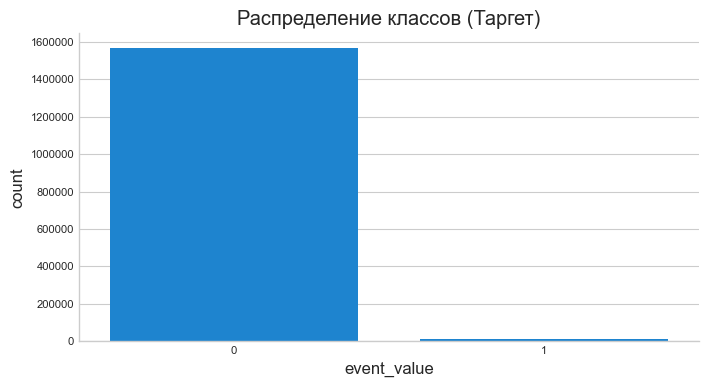

In [ ]:
task_type = cfg.task_type

plt.figure(figsize=(8, 4))

if task_type in ['binary', 'multiclass']:
    # Смотрим дисбаланс классов
    sns.countplot(data=df_hits, x=target_col)
    plt.title("Распределение классов (Таргет)")
elif task_type == 'regression':
    # Смотрим распределение (хвосты, выбросы)
    sns.histplot(data=df_hits, x=target_col, kde=True, bins=50)
    plt.title("Распределение целевой переменной (Регрессия)")

plt.show()

In [37]:
df_hits.groupby('session_id')[target_col].max().value_counts(normalize=True)

event_value
0    0.970618
1    0.029382
Name: proportion, dtype: float64

## AutoEDA

### ga_session

In [ ]:
print("Генерация HTML-отчета через Sweetviz...")

# Запускаем тяжелую артиллерию
report = sv.analyze(df)
output_path = reports_dir / "eda_report.html"
report.show_html(filepath=str(output_path), open_browser=True)

print(f"Отчет сохранен в: {output_path}")

Генерация HTML-отчета через Sweetviz...


                                             |          | [  0%]   00:00 -> (? left)

Report reports\eda_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
Отчет сохранен в: reports\eda_report.html


### ga_hits

In [39]:
print("Генерация HTML-отчета через Sweetviz...")

# Запускаем тяжелую артиллерию
report_hits = sv.analyze(df_hits, target_feat='event_value')
output_path = reports_dir / "target_eda_report.html"
report_hits.show_html(filepath=str(output_path), open_browser=True)

print(f"Отчет сохранен в: {output_path}")

Генерация HTML-отчета через Sweetviz...


                                             |          | [  0%]   00:00 -> (? left)

Report reports\target_eda_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
Отчет сохранен в: reports\target_eda_report.html


## Выводы по анализу ga_sessions:

### Типы данных
Все фичи являются типо object, однако имеются такие колонки как visit_date, visit_time которые могут/должны быть преобразованы в date, time соответственно. Device screen resolution можно распарсить в ширину и высоту а также площадь

### Missing Values

- Device_model: 99.12% пропусков + закодирована => удаляем фичу
- utm_keyword: ключевое слово 58.17% + закодирована => восстановить невозможно, но есть доминирующее ключевое слово, можно сделать фичу является ли ключевое слово доминантным или нет(пропуски = нет)
- device_os: 57.53% пропусков, есть 2 варианта заполнения т.к. есть 3 доминирующих операционных системы можно заполнить с сохранением пропорции, но более чистый вариант будет либо удалить, либо заполнить (not set)
- device_brand: 19,74% пропусков, нет ярко выраженного доминантного производителя, заполню (not set)
- utm_adcontent: 18.04% пропусков + закодирована, есть доминантный представитель, можно заполнить им, либо ввести новую категорию (not set) + 286 уникальных категорий из которых большую половину занимает 1 категорию, можно добавить фичу принадлежит ли данной фиче
- utm_campaign: 11.81% + закодирована: нет доминирующей категории => либо распределить в соответствии с пропорциями первых 4 т.к. они в сумме дают высокий процент по фиче либо удалить эти объекты
- utm_source: 0.01% + закодирована: либо удалить объекты либо попробовать восстановить из других закодированных фич где совпадения такие же как и в пропусках(например utm_medium + utm_campaign)

### Доминантные категории

- utm_adcontent
- utm_keyword
- device_os(android+ iOS+ Windows)

### Потенциальные аномалии и особенности данных

- Visit Time (Большое количество данных имеют дефолтные минуты и секунды)
- Visit Date (все данные за 2021 год)
- Visit number (имеются юзеры с очень большим количеством например 327 - очень похоже на бота а бот не совершает целевых действий есть смысл удалить такие данные)
- Device_category (tablet <1% можно объединить в 2 пункта или булеву фичу мобильное устройство?)
- Device_os (по сути все что есть это Android/IOS/PC os)
- Разрешение телефонов (по сути отличаются не очень сильно но могут влиять на целевое действие из-за разрешения т.к. модели могут быть разными, возможно стоит попробовать бины)
- Geo_country ( т.к. заказчик предоставляет услуги по россии стоит удалить строки которые не в россии С другой сторон пользуясь бизнес логикой иностранцы мониторят рынок аренды автомобилей перед скорым приездом, стоит разделить на россия/заграница и посмотреть на таргет)
- is_organic (72% не органичный трафик(платный)/ 28% это бесплатный трафик)
- is_social_media (15% из соцсетей)

### Correlation

- utm_medium с is_organic_medium (т.к. одна создана линейно из другой)
- device_brand с device_category (т.к. практически нет брендов с несколькими device_category)

### Duplicates

- Имеются дубли

## Выводы по анализу ga_hits

### Missing Values

- Вытащенные из ссылок мета данные дали не очень большое value т.к. очень много пропусков
- потенциально они могут использоваться для заполнения пропусков в ga_session в мета фичах

### Disbalance

- 97% - (0) / 3% - (1)
- целевой класс 3% от выборки

### Correlation

- event_category имеет высокую корреляцию с таргетом
например sub_submit имеет очень высокий процент конверсии в таргет действие 

### Duplicates 

- имеются дубли

## Merged

In [42]:

# --- 1. ПРЕДОБРАБОТКА ХИТОВ ---

# Заполняем пропуски в hit_time нулями (считаем, что это начало сессии)
df_hits['hit_time_clean'] = df_hits['hit_time'].fillna(0)

# Сортируем хиты внутри каждой сессии по порядку, чтобы логика времени и шагов работала железно
df_hits = df_hits.sort_values(by=['session_id', 'hit_number'])

# Считаем порядковый номер хита до таргета (внутри сессии)
# Создаем флаг, является ли данный конкретный хит таргетом
# (у тебя колонка с таргетом уже готова, допустим она называется 'is_target_hit')
df_hits['hit_counter'] = df_hits.groupby('session_id').cumcount() + 1

# Находим номер хита, на котором случился первый таргет в сессии
target_hit_numbers = df_hits[df_hits[target_col] == 1].groupby('session_id')['hit_counter'].min().reset_index()
target_hit_numbers.columns = ['session_id', 'first_target_hit_index']

In [44]:
print("Агрегируем продвинутые фичи из хитов...")

hits_smart_features = df_hits.groupby('session_id').agg(
    # Время первого и последнего хита (в миллисекундах от старта сессии)
    first_hit_time_ms=('hit_time_clean', 'min'),
    last_hit_time_ms=('hit_time_clean', 'max'),
    
    # Общее количество действий в сессии
    total_hits_count=('hit_number', 'count'),
    
    # Количество просмотренных уникальных машин за сессию (без учета 'no_car')
    unique_cars_viewed=('car_id', lambda x: x[x != 'no_car'].nunique()),
    
    # Общее количество просмотров карточек (один и тот же авто могли смотреть дважды)
    total_car_views=('car_id', lambda x: (x != 'no_car').sum()),
    
    # Целевое действие (если хотя бы раз был 1, то итог 1)
    target=(target_col, lambda x: int(any(x == 1)))
).reset_index()

# Считаем время между первым и последним хитом (длительность активности в мс)
hits_smart_features['session_duration_ms'] = hits_smart_features['last_hit_time_ms'] - hits_smart_features['first_hit_time_ms']

# Считаем среднее время между хитами (скорость кликов пользователя)
# Из общего времени вычитаем дельты, делим на количество шагов
hits_smart_features['avg_time_between_hits'] = np.where(
    hits_smart_features['total_hits_count'] > 1,
    hits_smart_features['session_duration_ms'] / (hits_smart_features['total_hits_count'] - 1),
    0
)

# Мержим индекс хита, на котором произошел таргет
hits_smart_features = pd.merge(hits_smart_features, target_hit_numbers, on='session_id', how='left')

# Количество действий ДО таргета:
# Если конверсия была, то это (индекс таргета - 1). Если конверсии не было, то это просто общее число хитов за сессию.
hits_smart_features['hits_before_target'] = np.where(
    hits_smart_features['first_target_hit_index'].notna(),
    hits_smart_features['first_target_hit_index'] - 1,
    hits_smart_features['total_hits_count']
)
# Удаляем технический индекс
hits_smart_features.drop(columns=['first_target_hit_index'], inplace=True)

Агрегируем продвинутые фичи из хитов...


In [45]:
print("Парсим даты и создаем календарные фичи...")

# Переводим колонку с датой в формат datetime (подставь имя своей колонки, например 'visit_date')
# Если дата записана как string '2023-11-20' или int 20231120:
df['visit_date_dt'] = pd.to_datetime(df['visit_date'], format='%Y-%m-%d') # или format='%Y%m%d'

# 1. Извлекаем день недели (0 = Понедельник, 6 = Воскресенье)
df['day_of_week'] = df['visit_date_dt'].dt.dayofweek

# 2. Считаем флаг выходного (Суббота = 5, Воскресенье = 6)
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

# 3. Извлекаем час визита (если в ga_sessions есть колонка visit_time вида '14:30:22' или просто час)
# Если visit_time это строка:
df['visit_hour'] = pd.to_datetime(df['visit_time'], format='%H:%M:%S').dt.hour
# Если visit_time это уже просто число (час), то оставляем как есть.

Парсим даты и создаем календарные фичи...


In [46]:
# Соединяем сессии и новые фичи хитов
final_dataset = pd.merge(df, hits_smart_features, on='session_id', how='left')

# Заполняем NaN нулями для сессий, у которых вообще не было хитов
cols_to_fill = ['total_hits_count', 'unique_cars_viewed', 'total_car_views', 
                'session_duration_ms', 'avg_time_between_hits', 'hits_before_target', 'target']
final_dataset[cols_to_fill] = final_dataset[cols_to_fill].fillna(0).astype(int)

In [49]:
print("Генерация HTML-отчета через Sweetviz...")

# Запускаем тяжелую артиллерию
report_fd = sv.analyze(
    final_dataset, 
    target_feat='target',
    pairwise_analysis='on' # гарантирует расчет сложных корреляций
)
output_path = reports_dir / "final_dataset_report.html"
report_fd.show_html(filepath=str(output_path), open_browser=True)

print(f"Отчет сохранен в: {output_path}")

Генерация HTML-отчета через Sweetviz...


                                             |          | [  0%]   00:00 -> (? left)

Report reports\final_dataset_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
Отчет сохранен в: reports\final_dataset_report.html
